# Libraries

In [17]:
import tensorflow as tf
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Load data

Load it in grayscale.

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/train/',
    color_mode='grayscale',
    batch_size=64,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/validation/',
    color_mode='grayscale',
    batch_size=64,
    shuffle=False
)

class_names = train_ds.class_names
class_names

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Found 96 files belonging to 3 classes.


['COVID-19', 'HEALTHY', 'PNEUMONIA']

In [61]:
# Extract true labels from the validation dataset
y_val = np.concatenate([y for _, y in val_ds], axis=0)

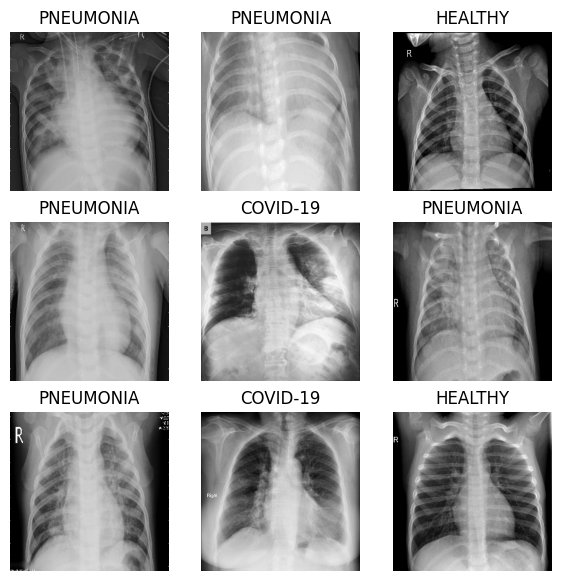

In [56]:
# Display image samples
plt.figure(figsize=(7, 7))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'), cmap='gray')
        plt.title(class_names[labels[i]])
        plt.axis('off')

In [5]:
# Image shapes
images[i].shape

TensorShape([256, 256, 1])

# Classical ML

For working with classical ML algorithms we need some kind of matrix or DataFrame format for representing the features.

The function below transforms images to a pandas DataFrame.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, PredefinedSplit
from sklearn.preprocessing import MinMaxScaler, RobustScaler, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

In [40]:
def single_split_cv(n_samples, test_size=0.2):
    """
    Returns a PredefinedSplit object for a single train/validation split

    Parameters
    ----------
    n_samples : int
        Total number of samples in your dataset.
    test_size : float
        Fraction of samples to use as test set.

    Returns
    -------
    cv : PredefinedSplit
         PredefinedSplit object ready for cross-validation.
    """
    split_idx = np.zeros(n_samples, dtype=int)
    n_test = int(n_samples * test_size)
    split_idx[-n_test:] = 1  # last samples are the test set
    return PredefinedSplit(split_idx)

In [41]:
def print_rs_metrics(rs_model):
    for t in ['train', 'test']:
        if t == 'test':
            print('X-Validation\n---------------')
        else:
            print('Train\n---------------')
        print('Accuracy:', rs_model.cv_results_[f'mean_{t}_score'][rs_model.best_index_].round(2))
        print()

In [42]:
def show_conf_matrix(rs_model, X_train, y_train, X_val, y_val):
    # Train best model on full train set
    rs_model.best_estimator_.fit(X_train, y_train)

    # Get predictions on validation set
    y_val_preds = rs_model.best_estimator_.predict(X_val)

    # Display confusion matrix
    ConfusionMatrixDisplay.from_predictions(y_val, y_val_preds)
    plt.title('Validation')
    plt.xticks(range(3), class_names)
    plt.yticks(range(3), class_names)
    plt.show()

In [43]:
def get_images_df(image_dataset):
    # get images from dataset in DF format
    df = []
    all_labels = []
    for images, labels in image_dataset:
        for img in images:
            flat_img = tf.keras.preprocessing.image.img_to_array(img, data_format=None, dtype=None).flatten()
            df.append(flat_img)
        all_labels.extend(labels.numpy())
    df = pd.DataFrame(df)
    df['label'] = all_labels
    return df

In [44]:
# Convert train, validation and test images to DF
df_train = get_images_df(train_ds)
df_val = get_images_df(val_ds)
df_test = get_images_df(test_ds)

In [45]:
print(df_train.shape)
df_train.head()

(351, 65537)


,0,1,2,3,4,5,6,7,8,9,...,65527,65528,65529,65530,65531,65532,65533,65534,65535,label
0,133.446396,124.478516,116.227005,117.622932,115.250984,114.443260,115.816406,114.301094,116.669922,118.816406,...,232.000000,229.224304,227.000000,224.091705,222.182617,220.000000,216.635529,211.085938,254.000000,0
1,50.556885,51.687500,50.000000,49.664307,49.062256,50.000000,50.000000,49.103760,49.000000,48.830811,...,162.312500,158.583740,157.260498,155.089844,157.625244,155.312500,152.222656,153.933594,150.241699,0
2,41.938568,47.705780,52.086197,54.049973,58.179764,55.633804,59.620987,53.624222,57.861038,53.714249,...,94.434967,78.643753,84.353516,78.782211,82.050629,70.695786,71.030334,84.028748,87.266510,0
3,11.279842,12.771484,12.028118,9.754784,12.468697,12.794781,11.542667,12.769428,15.005844,11.304844,...,9.631351,10.486698,9.000000,9.000000,10.000000,11.000000,11.000000,11.000000,8.529297,0
4,0.232422,0.505272,4.974266,2.320724,0.117378,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.289062,251.644531,0


In [46]:
# We can subsample the train data to train faster
df_train_sub = df_train.sample(100, random_state=42)
X_train = df_train_sub.drop('label', axis=1)
y_train = df_train_sub['label']

X_val = df_val.drop('label', axis=1)
y_val = df_val['label']

X_test = df_test.drop('label', axis=1)
y_test = df_test['label']

In [ ]:
# Perform a single train-validation split

ss = single_split_cv(n_samples=len(X_train), test_size=0.2)

## LR

Just try it by default, was taking too long to perform randomized search.

In [17]:
lr = Pipeline([
    ('scaler', RobustScaler()),
    ('lr', LogisticRegression(n_jobs=-1))
])

lr.fit(X_train, y_train)

Pipeline(steps=[('scaler', RobustScaler()),
                ('lr', LogisticRegression(n_jobs=-1))])

In [19]:
y_val_pred_lr = lr.predict(X_val)
print('Validation Accuracy:', round(accuracy_score(y_val, y_val_pred_lr), 2))

Validation Accuracy: 0.83


In [21]:
joblib.dump(lr, 'models/xrays/lr.joblib')

['models/xrays/lr.joblib']

## RF

In [ ]:
rf = RandomForestClassifier(100)

params = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'min_samples_split': [5, 10, 20, 30],
    'max_depth': [5, 8, 10, 20],
    'max_features': [None, 'sqrt', 'log2', 0.5, 0.7, 0.9],
    'max_samples': [None, 0.5, 0.7, 0.9],
    'max_leaf_nodes': [None, 20, 50],
}

rf_rs = RandomizedSearchCV(
    rf,
    n_iter=20,
    param_distributions=params,
    scoring='accuracy',
    cv=ss,
    refit='accuracy',
    return_train_score=True,
    n_jobs=-1
)

rf_rs.fit(X_train, y_train)

print(f'Best hyperparameters: {rf_rs.best_params_}\n')
print_rs_metrics(rf_rs)

Best hyperparameters: {'min_samples_split': 20, 'max_samples': 0.5, 'max_leaf_nodes': 20, 'max_features': 0.7, 'max_depth': 10, 'criterion': 'gini'}

Train
---------------
Accuracy: 0.95

X-Validation
---------------
Accuracy: 0.85



In [ ]:
joblib.dump(rf_rs.best_estimator_, 'models/xrays/rf.joblib')

['models/xrays/rf.joblib']

# CNN

In [ ]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/train/',
    color_mode='grayscale',
    batch_size=64,
    shuffle=True
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/validation/',
    color_mode='grayscale',
    batch_size=64,
    shuffle=False
)

class_names = train_ds.class_names
class_names

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.
Found 96 files belonging to 3 classes.


['COVID-19', 'HEALTHY', 'PNEUMONIA']

In [7]:
from keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Input, Rescaling,
    Dropout, BatchNormalization, Activation, GlobalAveragePooling2D
)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.models import Sequential
from keras.optimizers import Adam

## Functions

In [ ]:
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np
import glob
import os

def generate_submission(model, leaderboard_folder, submission_path, is_grayscale=False):
    paths = sorted(glob.glob(os.path.join(leaderboard_folder, "*")))
    # Sort by numeric part of the filename
    paths = sorted(paths, key=lambda x: int(os.path.splitext(os.path.basename(x))[0]))
    imgs = []
    names = []

    for p in paths:
        if is_grayscale:
            img = load_img(p, target_size=(256, 256), color_mode='grayscale')  # CAST!
        else:
            img = load_img(p, target_size=(256, 256))  # CAST!
        names.append(int(os.path.splitext(os.path.basename(p))[0]))
        imgs.append(img_to_array(img))

    X_lb = np.array(imgs)
    predictions = model.predict(X_lb, verbose=0)
    if predictions.shape[1] > 1:
        predictions = predictions.argmax(axis=1)

    submission_df = pd.DataFrame({
        'id': names,
        'prediction': predictions
    }).sort_values('id')

    submission_df.to_csv(submission_path, index=False)

## Grayscale

Keras can directly load data from a structure of directories, we don't need the pandas DataFrame we were using before.

The following example is not working well. Improve it! For example, adding more convolutional layer and/or more filters, etc.

In [18]:
cnn_model = Sequential([
    Input(shape=(256, 256, 1)),
    Rescaling(1./255),
    Conv2D(filters=12, kernel_size=2, strides=1, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.2),
    MaxPooling2D(pool_size=3),
    Conv2D(filters=12, kernel_size=2, strides=1, activation='relu', kernel_initializer='he_normal'),
    Dropout(0.1),
    MaxPooling2D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(128, activation='relu'),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

cnn_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [19]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

results = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    shuffle=False,  # If set to True we get a warning
    callbacks=[es]
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 311ms/step - accuracy: 0.4017 - loss: 4.3979 - val_accuracy: 0.3333 - val_loss: 1.2251
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 286ms/step - accuracy: 0.3675 - loss: 2.6255 - val_accuracy: 0.6111 - val_loss: 0.8609
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 294ms/step - accuracy: 0.4701 - loss: 1.5643 - val_accuracy: 0.8111 - val_loss: 0.6394
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.6268 - loss: 0.8961 - val_accuracy: 0.7444 - val_loss: 0.5958
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 0.6809 - loss: 0.7364 - val_accuracy: 0.7889 - val_loss: 0.5563
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 287ms/step - accuracy: 0.7236 - loss: 0.6381 - val_accuracy: 0.8000 - val_loss: 0.5358
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 289ms/step - accuracy: 0.7778 - loss: 0.5365 - val_accuracy: 0.6889 - val_loss: 0.5528
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 288ms/step - accuracy: 0.7863 - loss: 0.5010 - val_accuracy: 0.8889 - v

Save checkpoint:

In [21]:
cnn_model.save('models/xrays/cnn_grayscale.ckpt.keras')

In [46]:
cnn_model = tf.keras.models.load_model('models/xrays/cnn_grayscale.ckpt.keras')

At the end of the last `fit` the validation loss seemed unstable. Continue training but lower the LR:

In [47]:
cnn_model.optimizer.learning_rate.assign(3e-6)

<tf.Tensor: shape=(), dtype=float32, numpy=3.000000106112566e-06>

In [48]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

results = cnn_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=100,
    shuffle=False,  # If set to True we get a warning
    callbacks=[es]
)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - accuracy: 0.9829 - loss: 0.0399 - val_accuracy: 0.9556 - val_loss: 0.1476
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.9858 - loss: 0.0400 - val_accuracy: 0.9556 - val_loss: 0.1469
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 293ms/step - accuracy: 0.9772 - loss: 0.0456 - val_accuracy: 0.9556 - val_loss: 0.1460
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 292ms/step - accuracy: 0.9943 - loss: 0.0372 - val_accuracy: 0.9556 - val_loss: 0.1450
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 297ms/step - accuracy: 0.9915 - loss: 0.0372 - val_accuracy: 0.9556 - val_loss: 0.1442
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 307ms/step - accuracy: 0.9915 - loss: 0.0404 - val_accuracy: 0.9556 - val_loss: 0.1435
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 303ms/step - accuracy: 0.9915 - loss: 0.0353 - val_accuracy: 0.9556 - val_loss: 0.1428
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 299ms/step - accuracy: 0.9915 - loss: 0.0338 - val_accuracy: 0.9556 - v

In [49]:
loss, acc = cnn_model.evaluate(val_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.97


In [50]:
cnn_model.save('models/xrays/cnn_grayscale.keras')

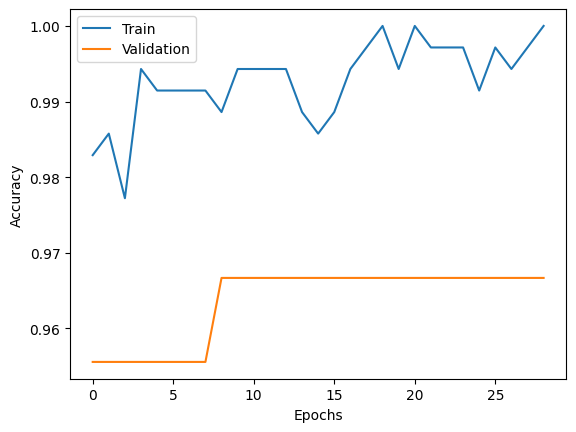

In [51]:
# Visualize the training metrics over the epochs
plt.plot(results.history['accuracy'], label='Train')
plt.plot(results.history['val_accuracy'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

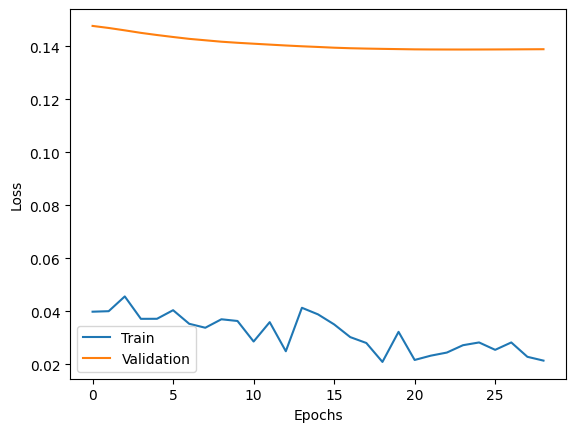

In [52]:
# Visualize the losses over the epochs
plt.plot(results.history['loss'], label='Train')
plt.plot(results.history['val_loss'], label='Validation')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [57]:
# Keras returns predicted probabilities by default
y_val_pred_probs = cnn_model.predict(val_ds, verbose=0)
y_val_pred = y_val_pred_probs.argmax(axis=1)

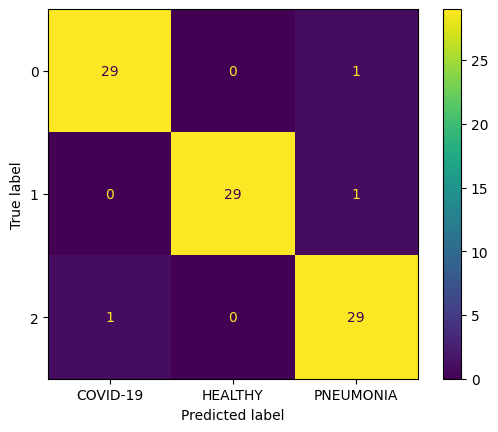

In [62]:
ConfusionMatrixDisplay.from_predictions(y_val, y_val_pred)
plt.xticks(range(3), val_ds.class_names)
plt.show()

## RGB

Same example as before, but working with RGB images instead.

In this case, we just need to specify we are receiving an input of (256, 256, 3).

In [63]:
train_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/train/',
    batch_size=64,
    shuffle=True
)

val_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/validation/',
    batch_size=64,
    shuffle=False
)

class_names = train_rgb_ds.class_names

Found 351 files belonging to 3 classes.
Found 90 files belonging to 3 classes.


In [64]:
cnn_rgb_model = Sequential([
    Input(shape=(256, 256, 3)),
    Rescaling(1./255),

    Conv2D(filters=16, kernel_size=5, strides=1, activation='relu'),
    MaxPooling2D(pool_size=3),
    Conv2D(filters=24, kernel_size=3, strides=1, activation='relu'),
    MaxPooling2D(pool_size=2),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(len(class_names), activation='softmax')
])

cnn_rgb_model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [65]:
cnn_rgb_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 252, 252, 16)   │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 84, 84, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 82, 82, 24)     │         3,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 41, 41, 24)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 40344)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │     5,164,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,177,307 (19.75 MB)

 Trainable params: 5,177,307 (19.75 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

cnn_rgb_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=200,
    batch_size=32,
    shuffle=False,
    callbacks=[es]
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 520ms/step - accuracy: 0.4729 - loss: 0.9923 - val_accuracy: 0.6222 - val_loss: 0.8004
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 499ms/step - accuracy: 0.5926 - loss: 0.8459 - val_accuracy: 0.6778 - val_loss: 0.6890
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 499ms/step - accuracy: 0.6781 - loss: 0.7231 - val_accuracy: 0.7556 - val_loss: 0.6244
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 512ms/step - accuracy: 0.7094 - loss: 0.6557 - val_accuracy: 0.8778 - val_loss: 0.5721
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 502ms/step - accuracy: 0.7949 - loss: 0.5832 - val_accuracy: 0.8444 - val_loss: 0.5215
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 501ms/step - accuracy: 0.7578 - loss: 0.5738 - val_accuracy: 0.8556 - val_loss: 0.4743
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 514ms/step - accuracy: 0.8063 - loss: 0.5053 - val_accuracy: 0.8111 - val_loss: 0.4391
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 508ms/step - accuracy: 0.7892 - loss: 0.5252 - val_accuracy: 0.8889 - v

In [68]:
loss, acc = cnn_rgb_model.evaluate(val_rgb_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.96


In [69]:
cnn_rgb_model.save('models/xrays/cnn_rgb.keras')

## KerasTuner

In this section I don't perform any intensive search. It is just here so you get the idea. You can make it as complicated and deep as you want.

In [36]:
import keras_tuner as kt

In [ ]:
def model_builder(hp):
    hp_filts_1 = hp.Int('n_kernels_1', min_value=8, max_value=64, step=8)
    cnn_custom_model = Sequential([
        Input(shape=(256, 256, 3)),
        Rescaling(1./255),
        Conv2D(filters=hp_filts_1, kernel_size=5, strides=1, activation='relu'),
        MaxPooling2D(pool_size=3),
    ])

    hp_n_layers = hp.Int('n_layers', min_value=0, max_value=3, step=1)
    for i, lay in enumerate(range(hp_n_layers)):
        hp_filts_n = hp.Int(f'hp_filts_{i+1}', min_value=8, max_value=64, step=8)
        cnn_custom_model.add(Conv2D(filters=hp_filts_n, kernel_size=3, strides=1, activation='relu'))
        if hp.Boolean('maxpooling'):
            cnn_custom_model.acc(MaxPooling2D(pool_size=2))
    cnn_custom_model.add(Flatten())
    cnn_custom_model.add(Dense(64, activation='relu'))
    cnn_custom_model.add(Dense(32, activation='relu'))
    cnn_custom_model.add(Dense(len(class_names), activation='softmax'))

    hp_lr = hp.Choice('learning_rate', [0.01, 0.001, 0.0001, 0.00001])
    cnn_custom_model.compile(
        optimizer=Adam(learning_rate=hp_lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return cnn_custom_model

In [ ]:
tuner = kt.RandomSearch(
    hypermodel=model_builder,
    objective="loss",
    max_trials=10,
    executions_per_trial=1,
    overwrite=True,
    project_name="rs_covid",
)

In [ ]:
tuner.search_space_summary()

Search space summary
Default search space size: 4
n_kernels_1 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
n_kernels_2 (Int)
{'default': None, 'conditions': [], 'min_value': 8, 'max_value': 64, 'step': 8, 'sampling': 'linear'}
n_layers (Int)
{'default': None, 'conditions': [], 'min_value': 0, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001, 1e-05], 'ordered': True}


In [ ]:
# Random search, only 5 epochs for speed. Ideally it should be more
tuner.search(train_rgb_ds, epochs=5)

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=5)[0]

Trial 10 Complete [00h 00m 25s]
loss: 0.6192677617073059

Best loss So Far: 0.1978771984577179
Total elapsed time: 00h 03m 17s


In [ ]:
# Build the model with the best hp
cnn_rgb_rs = model_builder(best_hps)
cnn_rgb_rs.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling_1 (Rescaling)     (None, 256, 256, 3)       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 252, 252, 56)      4256      
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 84, 84, 56)        0         
 g2D)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 395136)            0         
                                                                 
 dense_3 (Dense)             (None, 64)                25288768  
                                                                 
 dense_4 (Dense)             (None, 32)                2080      
                                                      

In [ ]:
es = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

cnn_rgb_rs.fit(train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=100,
    batch_size=32,
    callbacks=[es]
)

Epoch 1/100
11/11 [==============================] - 10s 756ms/step - loss: 5.4662 - accuracy: 0.3481 - val_loss: 1.0598 - val_accuracy: 0.3810
Epoch 2/100
11/11 [==============================] - 9s 732ms/step - loss: 1.0767 - accuracy: 0.4631 - val_loss: 1.0434 - val_accuracy: 0.5000
Epoch 3/100
11/11 [==============================] - 9s 711ms/step - loss: 0.8147 - accuracy: 0.6962 - val_loss: 0.5801 - val_accuracy: 0.8571
Epoch 4/100
11/11 [==============================] - 10s 810ms/step - loss: 0.4197 - accuracy: 0.8466 - val_loss: 1.6162 - val_accuracy: 0.4048
Epoch 5/100
11/11 [==============================] - 8s 705ms/step - loss: 0.3115 - accuracy: 0.8850 - val_loss: 0.4036 - val_accuracy: 0.8333
Epoch 6/100
11/11 [==============================] - 8s 703ms/step - loss: 0.1693 - accuracy: 0.9528 - val_loss: 0.4273 - val_accuracy: 0.8095
Epoch 7/100
11/11 [==============================] - 9s 734ms/step - loss: 0.2438 - accuracy: 0.8997 - val_loss: 0.4645 - val_accuracy: 0.76

In [ ]:
loss, acc = cnn_rgb_rs.evaluate(val_rgb_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.98


In [ ]:
cnn_rgb_rs.save('models/xrays/cnn_rgb_rs.keras')

## Data augmentation

### Example

In [66]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomRotation(0.05),
  tf.keras.layers.RandomTranslation(height_factor=(-0.1, 0.1), width_factor=(-0.1, 0.1)),
  tf.keras.layers.RandomBrightness(0.15),
])

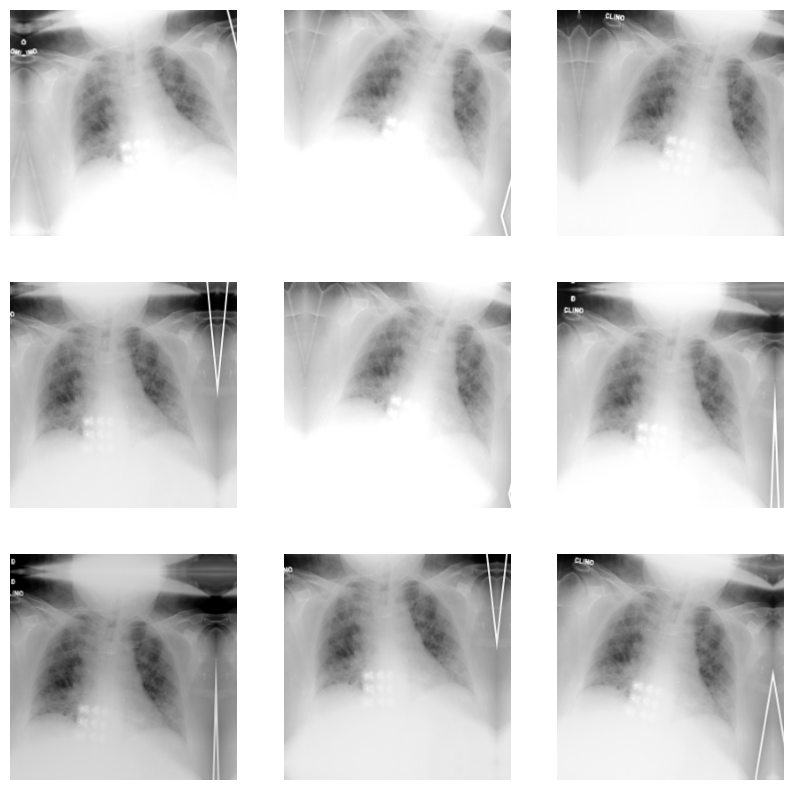

In [67]:
for image, _ in train_rgb_ds.take(1):
  plt.figure(figsize=(10, 10))
  first_image = image[0]
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
    plt.imshow(augmented_image[0] / 255, cmap='gray')
    plt.axis('off')

### Transfer

Instead of training a new network with data augmentation from scratch, load a previously trained NN (with the original data) and train it again with image transformations.

As with the loaded model we had a good performance, a good decision can be to freeze (make non-trainable) the already trained convolutional layers and add new and trainable ones.

In [70]:
cnn_rgb_augm_base = tf.keras.models.load_model('models/xrays/cnn_rgb.keras')
cnn_rgb_augm_base.layers

[<Rescaling name=rescaling_2, built=True>,
 <Conv2D name=conv2d_4, built=True>,
 <MaxPooling2D name=max_pooling2d_4, built=True>,
 <Conv2D name=conv2d_5, built=True>,
 <MaxPooling2D name=max_pooling2d_5, built=True>,
 <Flatten name=flatten_2, built=True>,
 <Dense name=dense_8, built=True>,
 <Dropout name=dropout_8, built=True>,
 <Dense name=dense_9, built=True>,
 <Dropout name=dropout_9, built=True>,
 <Dense name=dense_10, built=True>]

In [74]:
# Load first layers of a trained model
# Flatten is at index 5. We want layers up to index 4 without scaling.
cnn_layers_to_transfer = cnn_rgb_augm_base.layers[1:5]

# Freeze layers
for layer in cnn_layers_to_transfer:
    layer.trainable = False

In [75]:
cnn_rgb_augm_model = Sequential([
    Input(shape=(256, 256, 3)),

    # Augmentation
    tf.keras.layers.RandomBrightness(factor=0.15),
    tf.keras.layers.RandomContrast(factor=0.2),
    tf.keras.layers.RandomRotation(factor=0.05),
    tf.keras.layers.RandomTranslation(
        height_factor=(-0.05, 0.05),
        width_factor=(-0.05, 0.05)
    ),
    tf.keras.layers.RandomZoom(
        height_factor=(-0.05, 0.05),
        width_factor=(-0.05, 0.05)
    ),
    tf.keras.layers.GaussianNoise(0.01),

    Rescaling(1./255),

    # Add the frozen CNN layers
    # Use the asterisk (*) to unpack the list of layers
    *cnn_layers_to_transfer,

    # New convolutions
    Conv2D(filters=16, kernel_size=3, strides=1, activation='relu', kernel_initializer='he_normal'),
    MaxPooling2D(pool_size=2),

    # New top
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.2),
    Dense(256, activation='relu'),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(len(class_names), activation='softmax')
])

# Compile the model
cnn_rgb_augm_model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [76]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

cnn_rgb_augm_model.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=200,
    shuffle=False,
    callbacks=[es]
)

Epoch 1/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 312ms/step - accuracy: 0.3476 - loss: 1.0873 - val_accuracy: 0.6667 - val_loss: 1.0493
Epoch 2/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 273ms/step - accuracy: 0.4587 - loss: 1.0573 - val_accuracy: 0.7111 - val_loss: 1.0104
Epoch 3/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 272ms/step - accuracy: 0.4615 - loss: 1.0508 - val_accuracy: 0.7000 - val_loss: 0.9783
Epoch 4/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step - accuracy: 0.5527 - loss: 1.0184 - val_accuracy: 0.8333 - val_loss: 0.9448
Epoch 5/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 301ms/step - accuracy: 0.5698 - loss: 0.9878 - val_accuracy: 0.8333 - val_loss: 0.9135
Epoch 6/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.5356 - loss: 0.9837 - val_accuracy: 0.8222 - val_loss: 0.8812
Epoch 7/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 275ms/step - accuracy: 0.6467 - loss: 0.9395 - val_accuracy: 0.8222 - val_loss: 0.8432
Epoch 8/200
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 282ms/step - accuracy: 0.6439 - loss: 0.9071 - val_accuracy: 0.7889 - v

In [83]:
loss, acc = cnn_rgb_augm_model.evaluate(val_rgb_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.97


In [84]:
cnn_rgb_augm_model.save('models/xrays/cnn_rgb_augm.keras')

### Comparison on augmented data

What happens if we compare the performance on augmented data of the models trained and not trained with augmented data?

The model was trained with rotations of up 0.05 and brightness of 0.15. Let's try to put a bit more pressure and test the generalization with unseen rotations (up to 0.1) and unseen brightness (up to 0.25) changes.

In [85]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomRotation(0.1),
  tf.keras.layers.RandomBrightness(0.25),
])

In [86]:
# Crate new augmented dataset

new_valid_images = []
new_valid_labels = []
for images, labels in val_rgb_ds.take(1):
  for image, label in zip(images, labels):
    augmented_image = data_augmentation(tf.expand_dims(image, 0))
    new_valid_images.append(augmented_image[0])
    new_valid_labels.append(label)

Although the model trained with augmentation performs a bit worse on the real validation set, it performs much better on augmented data:

In [87]:
# Model trained without augmentation
loss, acc = cnn_rgb_model.evaluate(np.array(new_valid_images), np.array(new_valid_labels), verbose=0)
print('Normal RGB model')
print('New validation accuracy:', round(acc, 2))
print()

# Model trained with augmentation
loss, acc = cnn_rgb_augm_model.evaluate(np.array(new_valid_images), np.array(new_valid_labels), verbose=0)
print('Augmented RGB model')
print('New validation accuracy:', round(acc, 2))

Normal RGB model
New validation accuracy: 0.66

Augmented RGB model
New validation accuracy: 0.91


## Transfer learning imagenet

### MobileNetV2

In [88]:
from tensorflow.keras.applications import MobileNetV2

In [89]:
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    # Not the default size, but we can use it anyway
    input_shape=(256, 256, 3))

# Freeze all layers
for layer in base_model.layers:
    layer.trainable = False

/tmp/ipykernel_80505/3979374783.py:1: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


In [ ]:
# Create a new sequential model
cnn_transf = Sequential([
    Input(shape=(256, 256, 3)),
    
    # Augmentation
    tf.keras.layers.RandomBrightness(factor=0.05),
    tf.keras.layers.RandomContrast(factor=0.05),
    tf.keras.layers.RandomZoom(
        height_factor=(-0.02, 0.02),
        width_factor=(-0.02, 0.02)
    ),

    Rescaling(1./255),

    # Add the EfficientNetB0 layers
    base_model,
    
    Conv2D(16, kernel_size=2, strides=1, activation='leaky_relu'),
    MaxPooling2D(pool_size=2, strides=2),

    Flatten(),

    Dense(256, activation='relu'),
    Dropout(0.15),
    Dense(64, activation='relu'),
    Dropout(0.15),
    Dense(len(class_names), activation='softmax'),
])

# Compile the model
cnn_transf.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [94]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

cnn_transf.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=50,
    shuffle=False,
    callbacks=[es]
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.5071 - loss: 1.1729 - val_accuracy: 0.7889 - val_loss: 0.5934
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.8661 - loss: 0.4341 - val_accuracy: 0.9556 - val_loss: 0.2374
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9316 - loss: 0.2047 - val_accuracy: 0.9333 - val_loss: 0.2397
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9459 - loss: 0.1088 - val_accuracy: 0.9222 - val_loss: 0.2513
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9687 - loss: 0.0784 - val_accuracy: 0.9333 - val_loss: 0.2387
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9801 - loss: 0.0615 - val_accuracy: 0.9222 - val_loss: 0.2909
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9886 - loss: 0.0372 - val_accuracy: 0.9222 - val_loss: 0.2417
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9915 - loss: 0.0250 - val_accuracy: 0.9333 - val_loss: 0.2605
Epoch 9/50
6/6 

Save checkpoint:

In [95]:
cnn_transf.save('models/xrays/cnn_rgb_transf.ckpt.keras')

In [96]:
cnn_transf = tf.keras.models.load_model('models/xrays/cnn_rgb_transf.ckpt.keras')

At the end of the last `fit` the validation loss seemed unstable. Continue training but lower the LR:

In [97]:
cnn_transf.optimizer.learning_rate.assign(3e-4)

<tf.Tensor: shape=(), dtype=float32, numpy=0.0003000000142492354>

In [98]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

cnn_transf.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=50,
    shuffle=False,
    callbacks=[es]
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9402 - loss: 0.2228 - val_accuracy: 0.9444 - val_loss: 0.2412
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9573 - loss: 0.1765 - val_accuracy: 0.9556 - val_loss: 0.2330
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9630 - loss: 0.1296 - val_accuracy: 0.9333 - val_loss: 0.2207
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9744 - loss: 0.1109 - val_accuracy: 0.9444 - val_loss: 0.1976
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9772 - loss: 0.0854 - val_accuracy: 0.9444 - val_loss: 0.1853
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9829 - loss: 0.0757 - val_accuracy: 0.9444 - val_loss: 0.2012
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9858 - loss: 0.0607 - val_accuracy: 0.9333 - val_loss: 0.2309
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.9915 - loss: 0.0393 - val_accuracy: 0.9333 - val_loss: 0.2025
Epoch 9/50
6/6 

Save checkpoint:

In [100]:
cnn_transf.save('models/xrays/cnn_rgb_transf.ckpt2.keras')

In [113]:
cnn_transf = tf.keras.models.load_model('models/xrays/cnn_rgb_transf.ckpt2.keras')

At the end of the last `fit` the validation loss seemed unstable. Continue training but lower the LR:

In [114]:
cnn_transf.optimizer.learning_rate.assign(3e-6)

<tf.Tensor: shape=(), dtype=float32, numpy=3.000000106112566e-06>

In [115]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

cnn_transf.fit(
    train_rgb_ds,
    validation_data=val_rgb_ds,
    epochs=50,
    shuffle=False,
    callbacks=[es]
)

Epoch 1/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.9886 - loss: 0.0582 - val_accuracy: 0.9444 - val_loss: 0.1851
Epoch 2/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9744 - loss: 0.0808 - val_accuracy: 0.9444 - val_loss: 0.1849
Epoch 3/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9658 - loss: 0.0817 - val_accuracy: 0.9444 - val_loss: 0.1845
Epoch 4/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9801 - loss: 0.0614 - val_accuracy: 0.9444 - val_loss: 0.1843
Epoch 5/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9886 - loss: 0.0583 - val_accuracy: 0.9444 - val_loss: 0.1842
Epoch 6/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9829 - loss: 0.0742 - val_accuracy: 0.9444 - val_loss: 0.1839
Epoch 7/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9658 - loss: 0.0869 - val_accuracy: 0.9444 - val_loss: 0.1836
Epoch 8/50
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.9687 - loss: 0.0800 - val_accuracy: 0.9444 - val_loss: 0.1834
Epoch 9/50
6/6 

In [116]:
loss, acc = cnn_transf.evaluate(val_rgb_ds, verbose=0)
print('Validation accuracy:', round(acc, 2))

Validation accuracy: 0.94


In [117]:
cnn_transf.save('models/xrays/cnn_rgb_transf.keras')

# Test

In [212]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/test/',
    color_mode='grayscale',
    batch_size=64,
    shuffle=False
)

test_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/test/',
    batch_size=64,
    shuffle=False
)

Found 96 files belonging to 3 classes.
Found 96 files belonging to 3 classes.


## Classical

In [30]:
# Full training set without subsample
X_train = df_train.drop('label', axis=1)
y_train = df_train['label']

# Concatenate with validation
X_train_full = pd.concat([X_train, X_val], axis=0)
y_train_full = pd.concat([y_train, y_val], axis=0)

In [ ]:
model_files = {
    'lr': 'lr.joblib',
    'rf': 'rf.joblib',
}
models_class = {}

for name, filename in model_files.items():
    models_class[name] = joblib.load(f'models/xrays/{filename}')

In [ ]:
accs_class = {
    'train': [],
    'val': [],
    'test': []
}

for name, model in models_class.items():
    # # Train with whole train and validation set
    # model.fit(X_train_full, y_train_full)

    acc_train = accuracy_score(y_train, model.predict(X_train))
    acc_test = accuracy_score(y_test, model.predict(X_test))

    accs_class['train'].append(acc_train)
    accs_class['test'].append(acc_test)

    print(name)
    print('--------------')
    print('Train accuracy:', round(acc_train, 2))
    print('Test accuracy:', round(acc_test, 2))
    print()

lr
--------------
Train full accuracy: 0.88
Test accuracy: 0.83

knn
--------------
Train full accuracy: 0.85
Test accuracy: 0.85

rf
--------------
Train full accuracy: 0.84
Test accuracy: 0.76



## CNNs

In [188]:
models_files = {
    'cnn_gray': 'cnn_grayscale.keras',
    'cnn_rgb': 'cnn_rgb.keras',
    'cnn_rgb_augm': 'cnn_rgb_augm.keras',
    'cnn_rgb_transf': 'cnn_rgb_transf.keras'
}
models_cnn = {}

for name, filename in models_files.items():
    models_cnn[name] = tf.keras.models.load_model(f'models/xrays/{filename}')

In [ ]:
accs_cnn = {
    'train': [],
    'val': [],
    'test': []
}

for name, model in models_cnn.items():
    if 'gray' in name:
        # grayscale data
        loss_train, acc_train = model.evaluate(train_ds, verbose=0)
        loss_val, acc_val = model.evaluate(val_ds, verbose=0)
        loss_test, acc_test = model.evaluate(test_ds, verbose=0)
    else:
        # RGB data
        loss_train, acc_train = model.evaluate(train_rgb_ds, verbose=0)
        loss_val, acc_val = model.evaluate(val_rgb_ds, verbose=0)
        loss_test, acc_test = model.evaluate(test_rgb_ds, verbose=0)

    accs_cnn['train'].append(acc_train)
    accs_cnn['val'].append(acc_val)
    accs_cnn['test'].append(acc_test)

In [127]:
pd.DataFrame(accs_cnn, index=models_cnn.keys()).round(2)

,train,val,test
cnn_gray,1.00,0.97,0.90
cnn_rgb,0.99,0.96,0.90
cnn_rgb_augm,0.94,0.97,0.94
cnn_rgb_transf,0.99,0.94,0.93


# Submission

Train some epochs with validation data and use test as validation for early stopping. In this way we increase the training data before submitting.

In [ ]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/validation/',
    color_mode='grayscale',
    batch_size=15,
    shuffle=True
)

val_rgb_ds = tf.keras.utils.image_dataset_from_directory(
    '../data/x-rays/validation/',
    batch_size=15,
    shuffle=True
)

In [213]:
es = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

Train 3 models with validation data:

In [214]:
models_files = {
    'cnn_gray': 'cnn_grayscale.keras',
    'cnn_rgb': 'cnn_rgb.keras',
    'cnn_rgb_augm': 'cnn_rgb_augm.keras',
    'cnn_rgb_transf': 'cnn_rgb_transf.keras'
}
models_cnn = {}

for name, filename in models_files.items():
    models_cnn[name] = tf.keras.models.load_model(f'models/xrays/{filename}')

In [215]:
for name in ['cnn_gray', 'cnn_rgb_augm', 'cnn_rgb_transf']:
    print()
    print('==================')
    print(name)
    print('==================')
    print()

    # current_lr = models_cnn[name].optimizer.learning_rate.value
    # print(current_lr)
    models_cnn[name].optimizer.learning_rate.assign(1e-5)

    if 'gray' in name:
        models_cnn[name].fit(
            # combined_train_ds,
            train_ds,
            validation_data=test_ds,
            epochs=20,
            shuffle=False,
            callbacks=[es]
        )
    else:
        # Use RGB data
        models_cnn[name].fit(
            # combined_train_rgb_ds,
            train_rgb_ds,
            validation_data=test_rgb_ds,
            epochs=20,
            shuffle=False,
            callbacks=[es]
        )


cnn_gray

Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 310ms/step - accuracy: 1.0000 - loss: 0.0235 - val_accuracy: 0.8958 - val_loss: 0.2211
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.9915 - loss: 0.0371 - val_accuracy: 0.8958 - val_loss: 0.2186
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 0.9972 - loss: 0.0207 - val_accuracy: 0.9062 - val_loss: 0.2165
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 296ms/step - accuracy: 1.0000 - loss: 0.0249 - val_accuracy: 0.9062 - val_loss: 0.2151
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 295ms/step - accuracy: 0.9943 - loss: 0.0266 - val_accuracy: 0.9167 - val_loss: 0.2141
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 283ms/step - accuracy: 0.9943 - loss: 0.0263 - val_accuracy: 0.9167 - val_loss: 0.2136
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 291ms/step - accuracy: 1.0000 - loss: 0.0248 - val_accuracy: 0.9271 - val_loss: 0.2135
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step - accuracy: 1.0000 - loss: 0.0230 - val_accuracy: 0.9271 

Generate a different submission for each model:

In [216]:
for name in ['cnn_gray', 'cnn_rgb_augm', 'cnn_rgb_transf']:
    generate_submission(
        models_cnn[name],
        leaderboard_folder='../data/x-rays/leaderboard',
        submission_path=f'../data/x-rays/submission_{name}.csv',
        is_grayscale=True if 'gray' in name else False
    )

Create a submission file for each model:

In [217]:
submissions = {}

for name in ['cnn_gray', 'cnn_rgb_augm', 'cnn_rgb_transf']:
    submissions[name] = pd.read_csv(f'../data/x-rays/submission_{name}.csv').sort_values('id')


Do majority voting:

In [218]:
votes_df = pd.DataFrame({'id': submissions['cnn_gray']['id']})
for name, submission in submissions.items():
    votes_df[name] = submission['prediction']
votes_df

,id,cnn_gray,cnn_rgb_augm,cnn_rgb_transf
0,1,0,0,0
1,2,1,1,1
2,3,1,0,1
3,4,0,0,0
4,5,0,0,0
...,...,...,...,...
111,112,1,1,1
112,113,2,2,2
113,114,1,1,1
114,115,2,2,2


In [219]:
votes_df['prediction'] = votes_df.drop(columns=['id']).mode(axis=1)[0].astype(int)
votes_df

,id,cnn_gray,cnn_rgb_augm,cnn_rgb_transf,prediction
0,1,0,0,0,0
1,2,1,1,1,1
2,3,1,0,1,1
3,4,0,0,0,0
4,5,0,0,0,0
...,...,...,...,...,...
111,112,1,1,1,1
112,113,2,2,2,2
113,114,1,1,1,1
114,115,2,2,2,2


In [220]:
votes_df[['id', 'prediction']].to_csv('../data/x-rays/submission_average.csv', index=False)